TOP 5 SKILLS FOR DATA ANALYSTS PER **MONTH**

In [22]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

df_analyst = df[df['job_title_short'] == 'Data Analyst'].copy()


df_analyst.info()



<class 'pandas.DataFrame'>
Index: 196075 entries, 1 to 785737
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        196075 non-null  str           
 1   job_title              196075 non-null  str           
 2   job_location           195801 non-null  str           
 3   job_via                196067 non-null  str           
 4   job_schedule_type      191475 non-null  str           
 5   job_work_from_home     196075 non-null  bool          
 6   search_location        196075 non-null  str           
 7   job_posted_date        196075 non-null  datetime64[us]
 8   job_no_degree_mention  196075 non-null  bool          
 9   job_health_insurance   196075 non-null  bool          
 10  job_country            196067 non-null  str           
 11  salary_rate            9746 non-null    str           
 12  salary_year_avg        5451 non-null    float64       
 13  

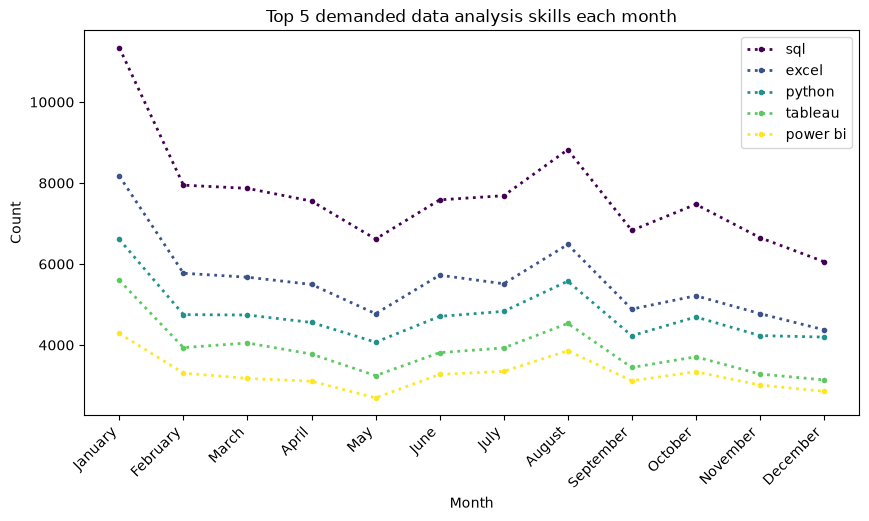

In [ ]:
df_analyst['month_no'] = df_analyst['month_no'] = df_analyst['job_posted_date'].dt.month
df_pivot = df_analyst.explode('job_skills').copy()
df_pivot = df_pivot.pivot_table( index ='month_no', columns = 'job_skills', aggfunc = 'size', fill_value = 0 ).copy()
df_pivot = df_pivot.apply(lambda x: x.sort_values(ascending = False).head(5), axis = 1)
df_pivot.reset_index(inplace = True)
df_pivot['month_name'] = df_pivot['month_no'].apply(lambda x : pd.to_datetime(x, format = '%m').strftime('%B'))
df_pivot.drop(columns = 'month_no', inplace = True)


